# Twitter Sentiment Analysis

#### *Joey Wong & Yibin Li*

The following Python notebook conducts a sentiment analysis on a dataset of tweets from users on the Twitter platform. The dataset can be found at the following link: 
https://www.kaggle.com/datasets/kazanova/sentiment140/data.

Tweets marked as "0" or "NEGATIVE" in the "target" column are regarded as negative sentiment tweets while those marked as "1" or "POSTIVE" in the "taret" column are regarded as positive sentiment tweets.

Our project can be found on GitHub: 
https://github.com/joey24wong/twitter-sentiment-analysis

## Steps:

### 1: Reading the Data and Exploratory Data Analysis
- Reading the data into a pandas dataframe
- Analyzing data (shape, null values, duplicates, data types)
- Relevant columns: Deciding which columns will be needed in the preprocessing stage

### 2: Data Cleaning & Preprocessing
- Change "text" column to lowercase
- Remove special characters
- Remove HTML tags & links
- Remove common words / stop words
- Remove non-english tweets

### 3: TF-IDF & Multinomial Naive Bayes / Logistic Regression
- Word embedding with TF-IDF (used to evaluate word importance in tweets)
    - Transform train and test data
- Fit multinomial Naive Bayes model to training data
- Fit logistic regression model to training data
- Predict train & test sets
- Evaluate results using precision, recall, and accuracy
- Display results in confusion matrix

### 4: Word2Vector & Neural Network
- Word embedding with Word2Vector
    - Transform train and test data
    - Embedding
    - Tokenizing
    - Label encoding
- Create embedding matrix / layer
- Fit dense neural network to training data
- Predict test dataset
- Evaluate results using precision, recall, and accuracy
- Display results in confusion matrix

### 5: Results & Future Steps
- Evaluate results of various models and determine best performer
- Further steps to improve sentiment analysis
- Potential challenges

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import fasttext
import gensim
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from collections import Counter

from huggingface_hub import hf_hub_download

from keras.layers import Embedding
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.preprocessing.text import Tokenizer
TOKENIZER_MODEL = "tokenizer.pkl"
from tensorflow.keras.preprocessing.sequence import pad_sequences

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/liyibin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 1. Reading the Data & Exploratory Data Analysis:

In [4]:
twit = pd.read_csv("training.1600000.processed.noemoticon.csv", header=None, encoding='latin1')

headers = ['target', 'id', 'date', 'flag', 'user', 'text']
twit.columns = headers

twit.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [5]:
print(twit.shape)

(1600000, 6)


#### Finding null values and duplicate rows in the data:
- No null values were found
- No duplictes were found

In [6]:
twit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   id      1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   flag    1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [7]:
twit.drop_duplicates(keep='first',inplace=True)
print(twit.shape)

(1600000, 6)


#### Analyis of Target Column

Target column contains 2 values:
1. 0 (negative sentiment)
2. 4 (positive sentiment)

We decied to change positive sentiment from 4 to 1 for simplicity

In [8]:
twit.nunique()

target          2
id        1598315
date       774363
flag            1
user       659775
text      1581466
dtype: int64

In [9]:
print(twit['target'].unique())

[0 4]


In [10]:
twit['target'].replace(4,1,inplace=True)
print(twit['target'].unique())

[0 1]


/tmp/ipykernel_12873/992296819.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  twit['target'].replace(4,1,inplace=True)


<function matplotlib.pyplot.show(close=None, block=None)>

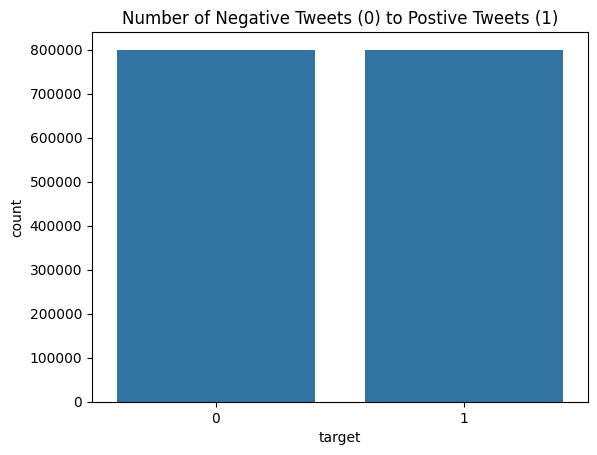

In [11]:
sns.countplot(data=twit, x='target')
plt.title('Number of Negative Tweets (0) to Postive Tweets (1)')
plt.show

There are approximately an even number of negative and positive tweets in this dataset

#### Analysis of Date Column:

In [12]:
twit['date'] = pd.to_datetime(twit['date'])
twit['month'] = twit['date'].dt.month_name()
twit['year'] = twit['date'].dt.year

twit.drop(['date'], axis=1, inplace=True)

twit.head()

/tmp/ipykernel_12873/1806862209.py:1: FutureWarning: Parsed string "Mon Apr 06 22:19:45 PDT 2009" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  twit['date'] = pd.to_datetime(twit['date'])


,target,id,flag,user,text,month,year
0,0,1467810369,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",April,2009
1,0,1467810672,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,April,2009
2,0,1467810917,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,April,2009
3,0,1467811184,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,April,2009
4,0,1467811193,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",April,2009


In [13]:
print(twit['year'].unique())
print(twit['month'].unique())

[2009]
['April' 'May' 'June']


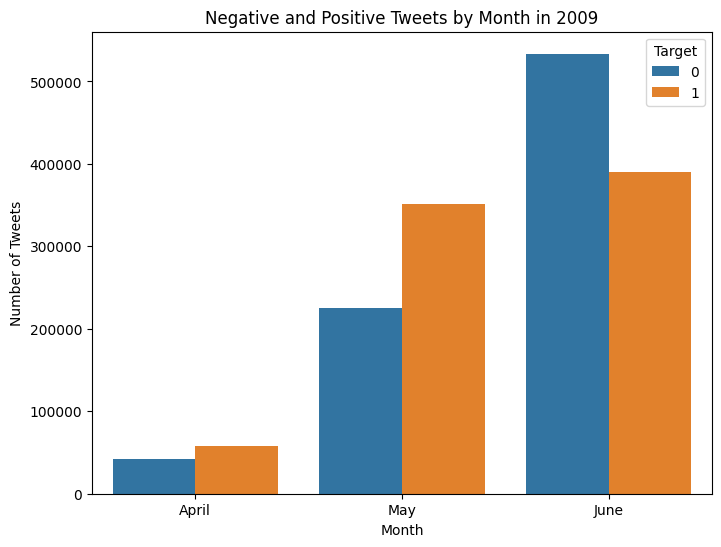

In [14]:
plt.figure(figsize=(8, 6))
sns.countplot(data=twit, x='month', hue='target')
plt.title('Negative and Positive Tweets by Month in 2009')
plt.xlabel('Month')
plt.ylabel('Number of Tweets')
plt.legend(title='Target')
plt.show()

Further analysis can be done to determine whether month has an impact on tweet sentiment in this dataset. It appears as though there were more positive tweets in May, 2009 while there were more negative tweets in June, 2009. For this sentiment analysis, we will focus more on the content of the tweets to determine sentiment.

#### Analysis of User Column:

In [15]:
user_tweet_count = twit['user'].value_counts()

max_num = user_tweet_count.max()
most_tweets = twit['user'].mode()

print(f'User with the most number of tweets: {most_tweets[0]}')
print(f'Most tweets by a single user: {max_num}')

User with the most number of tweets: lost_dog
Most tweets by a single user: 549


In [16]:
print(f'{max_num / twit.shape[0] * 100}%')

0.0343125%


Since the dataset contains 1,600,000 rows and the most number of tweets by a single user is 549, the tweet's user is not necessarily an important column in determining sentiment

#### Dropping Irrelevant Columns:

The only columns that matter are the target column (used for classifying a positive or negative sentiment) and the text column (indicates the tweet that was made)

- id is an irrelevant column due to there being an almost identical number of ids compared to total tweets. This data is not useful
- date may have some effect on sentiment, but for this analysis it will be irrelevant because the data is accumulated from 3 months (April, May, June) during the year 2009
- year can be dropped because all of the data is from 2009
- flag can be dropped because there is only 1 value in this column
- user is irrelevant due to the high number of tweets in the dataset

In [17]:
twit.drop(['id', 'month', 'year', 'flag', 'user'], axis=1, inplace=True)
twit.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


## 2. Data Cleaning & Preprocessing:

#### Changing the 'text' column to lowercase:

In [18]:
twit['text'] = twit['text'].str.lower()

twit.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - awww, t..."
1,0,is upset that he can't update his facebook by ...
2,0,@kenichan i dived many times for the ball. man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


#### Removing Special Characters ($, &, @, *, etc.):

Also removing Users, HTML tags, and links

In [19]:
def remove_special_char(tweet):
    tweet = re.sub(r'@\S+', '', tweet)
    tweet = re.sub(r'<.*?>', '', tweet)
    tweet = re.sub(r'http\S+', '', tweet)
    tweet = re.sub('[^a-zA-Z]', ' ', tweet)
    return tweet.strip()

In [20]:
twit['text'] = twit['text'].apply(remove_special_char)

twit.head()

,target,text
0,0,awww that s a bummer you shoulda got david ...
1,0,is upset that he can t update his facebook by ...
2,0,i dived many times for the ball managed to sa...
3,0,my whole body feels itchy and like its on fire
4,0,no it s not behaving at all i m mad why am ...


#### Finding and Removing 25 Most Common Words + Stopwords:

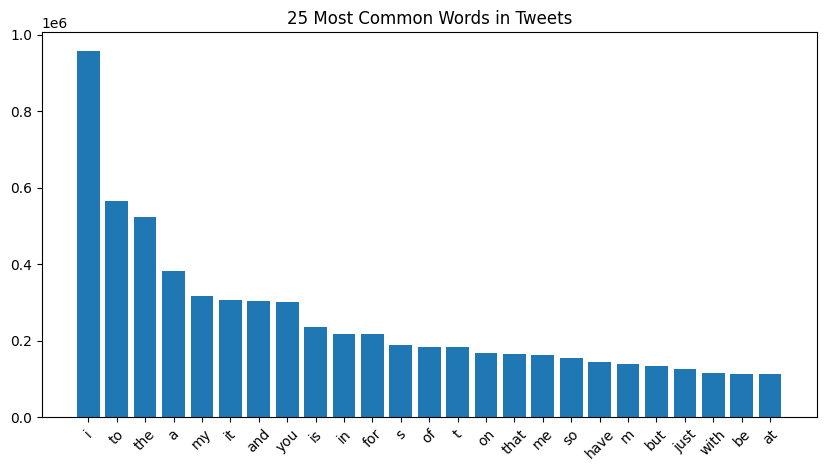

In [21]:
most_common = Counter(" ".join(twit['text']).split()).most_common(25)

common_word, cnt = zip(*most_common)

plt.figure(figsize=(10,5))
plt.bar(common_word,cnt)
plt.xticks(rotation=45)
plt.title("25 Most Common Words in Tweets")
plt.show()

In [22]:
def remove_top_25(tweet):
    words = tweet.split()
    cleaned_words = [i for i in words if i not in common_word]
    return " ".join(cleaned_words)

In [23]:
twit['text'] = twit['text'].apply(remove_top_25)

twit.head()

,target,text
0,0,awww bummer shoulda got david carr third day do d
1,0,upset he can update his facebook by texting mi...
2,0,dived many times ball managed save rest go out...
3,0,whole body feels itchy like its fire
4,0,no not behaving all mad why am here because ca...


In [24]:
stop_words = stopwords.words('english')
stemmer = SnowballStemmer('english')

def remove_stopwords(tweet, stem=False):
    tokens = []
    for token in tweet.split():
        if token not in stop_words:
            if stem:
                tokens.append(stemmer.stem(token))
            else:
                tokens.append(token)
    return " ".join(tokens)

In [25]:
twit['text'] = twit['text'].apply(remove_stopwords)

twit.head()

,target,text
0,0,awww bummer shoulda got david carr third day
1,0,upset update facebook texting might cry result...
2,0,dived many times ball managed save rest go bounds
3,0,whole body feels itchy like fire
4,0,behaving mad see


#### Removing non-english tweets from data:

In [26]:
text_list = twit['text'].tolist()

print(text_list[:5])

['awww bummer shoulda got david carr third day', 'upset update facebook texting might cry result school today also blah', 'dived many times ball managed save rest go bounds', 'whole body feels itchy like fire', 'behaving mad see']


In [ ]:
model_path = hf_hub_download(repo_id="facebook/fasttext-language-identification", filename="model.bin")
model = fasttext.load_model('lid.176.bin')

index_list = []
with open("filtered_texts2.txt", "w", encoding='utf-8') as file:
    for index, text in enumerate(text_list):
        prediction, score = model.predict(text)
        label = prediction[0]
        # print(prediction)
        label_list = ["__label__en","__label__eng_Latn"]
        if label not in label_list:
            file.write(f"Index: {index}, Text: {text}\n")
            index_list.append(index)
            
# print (index_list)
print(f'Number of Non-English tweets found: {len(index_list)}')

twit = twit.drop(index=index_list, errors='ignore').reset_index(drop=True)
twit.head(10)

[8, 9, 27, 34, 62, 125, 180, 258, 274, 283, 309, 370, 408, 452, 459, 469, 470, 490, 495, 553, 565, 594, 637, 663, 668, 671, 709, 749, 750, 841, 859, 869, 904, 928, 936, 1006, 1058, 1081, 1144, 1151, 1156, 1159, 1162, 1236, 1285, 1317, 1342, 1348, 1395, 1409, 1520, 1557, 1564, 1618, 1635, 1688, 1702, 1721, 1761, 1780, 1793, 1800, 1806, 1815, 1831, 1857, 1862, 1904, 1909, 1927, 1936, 1950, 1963, 2005, 2015, 2125, 2129, 2193, 2204, 2225, 2232, 2254, 2268, 2272, 2280, 2314, 2319, 2333, 2360, 2379, 2388, 2414, 2473, 2479, 2538, 2575, 2678, 2870, 2960, 2967, 2973, 2983, 2989, 3009, 3017, 3023, 3069, 3119, 3160, 3222, 3223, 3257, 3292, 3326, 3328, 3342, 3409, 3425, 3441, 3499, 3507, 3515, 3526, 3537, 3599, 3635, 3644, 3659, 3688, 3831, 3846, 3896, 3933, 3934, 3962, 3994, 4043, 4065, 4073, 4097, 4099, 4100, 4108, 4187, 4203, 4217, 4255, 4264, 4268, 4320, 4379, 4382, 4394, 4414, 4421, 4424, 4463, 4499, 4556, 4596, 4605, 4645, 4658, 4688, 4708, 4745, 4763, 4775, 4781, 4790, 4800, 4812, 4853, 487

,target,text
0,0,awww bummer shoulda got david carr third day
1,0,upset update facebook texting might cry result...
2,0,dived many times ball managed save rest go bounds
3,0,whole body feels itchy like fire
4,0,behaving mad see
5,0,whole crew
6,0,need hug
7,0,hey long time see yes rains bit bit lol fine t...
8,0,spring break plain city snowing
9,0,pierced ears


## 3.1 Model Application: TF-IDF and Multinomial Naive Bayes

#### Splitting the data into Train/Test data:

In [30]:
X,y = twit['text'], twit['target']
m = 0.2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = m, random_state=10)

In [27]:
featurizer = TfidfVectorizer()

X_train_tfidf = featurizer.fit_transform(X_train)
X_test_tfidf = featurizer.transform(X_test)

Classification Report (Train):
               precision    recall  f1-score   support

           0       0.79      0.81      0.80    609451
           1       0.80      0.78      0.79    602573

    accuracy                           0.79   1212024
   macro avg       0.79      0.79      0.79   1212024
weighted avg       0.79      0.79      0.79   1212024

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.76      0.78      0.77    152501
           1       0.77      0.74      0.76    150505

    accuracy                           0.76    303006
   macro avg       0.76      0.76      0.76    303006
weighted avg       0.76      0.76      0.76    303006



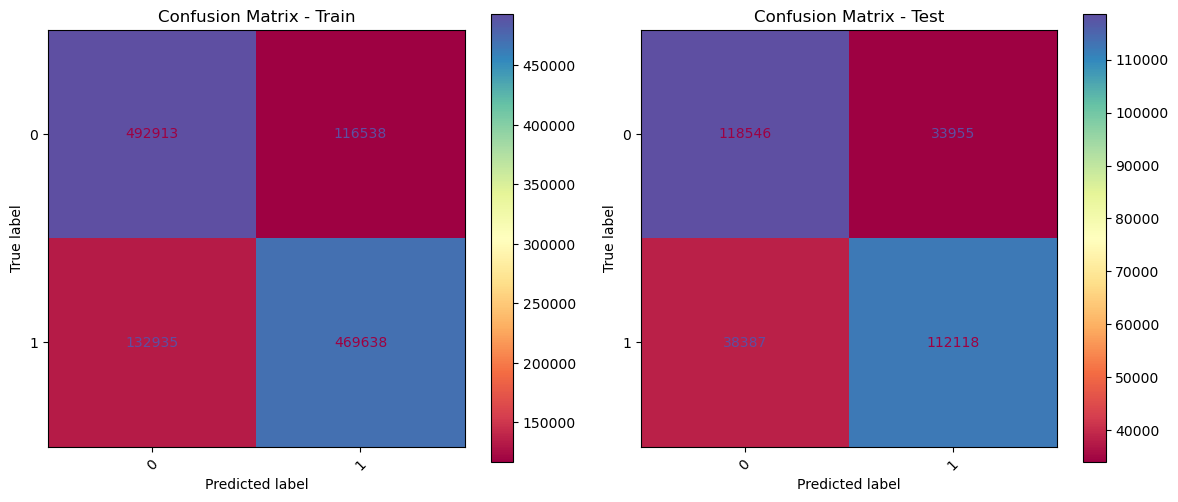

In [28]:
mnb = MultinomialNB()
mnb.fit(X_train_tfidf, y_train)

mnb_train_pred = mnb.predict(X_train_tfidf)
mnb_test_pred = mnb.predict(X_test_tfidf)

C_train = confusion_matrix(y_train, mnb_train_pred)
C_test = confusion_matrix(y_test, mnb_test_pred)

print("Classification Report (Train):\n", classification_report(y_train, mnb_train_pred))
print("Classification Report (Test):\n", classification_report(y_test, mnb_test_pred))

fig, axes = plt.subplots(1, 2, figsize=(12,5))

matrix_train = ConfusionMatrixDisplay(C_train, display_labels=mnb.classes_)
matrix_train.plot(ax=axes[0], cmap="Spectral", xticks_rotation=45, values_format='d')
axes[0].set_title("Confusion Matrix - Train")

matrix_test = ConfusionMatrixDisplay(C_test, display_labels=mnb.classes_)
matrix_test.plot(ax=axes[1], cmap="Spectral", xticks_rotation=45, values_format='d')
axes[1].set_title("Confusion Matrix - Test")

plt.tight_layout()
plt.show()

In [29]:
def score_table(name,pred,actual):
    accuracy  = accuracy_score(actual,pred)
    precision = precision_score(actual,pred,average='macro')
    recall    = recall_score(actual,pred,average='macro')
    f1        = f1_score(actual,pred,average='macro')
    
    data = [name, accuracy, precision, recall, f1]
    headers = ['Model', 'Accuracy', 'Precision', 'Recall', 'f1']
    
    result = pd.DataFrame([data], columns=headers)
    
    return result

In [30]:
mnb_train_result = score_table('MNB (train)', mnb_train_pred, y_train)
mnb_test_result = score_table('MNB (test)', mnb_test_pred, y_test)

mnb_results = pd.concat([mnb_train_result, mnb_test_result], axis=0)
mnb_results

,Model,Accuracy,Precision,Recall,f1
0,MNB (train),0.794168,0.794391,0.794085,0.794092
0,MNB (test),0.761252,0.761470,0.761146,0.761145


## 3.2 Model Application: TF-IDF and Logistic Regression

C:\Users\joey2\AppData\Local\Temp\ipykernel_35756\3674867161.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  lr.fit(X_train_tfidf, y_train.ravel())
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


convergence after 24 epochs took 20 seconds
Classification Report (Train):
               precision    recall  f1-score   support

           0       0.81      0.78      0.80    609451
           1       0.79      0.82      0.80    602573

    accuracy                           0.80   1212024
   macro avg       0.80      0.80      0.80   1212024
weighted avg       0.80      0.80      0.80   1212024

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.79      0.76      0.78    152501
           1       0.77      0.79      0.78    150505

    accuracy                           0.78    303006
   macro avg       0.78      0.78      0.78    303006
weighted avg       0.78      0.78      0.78    303006



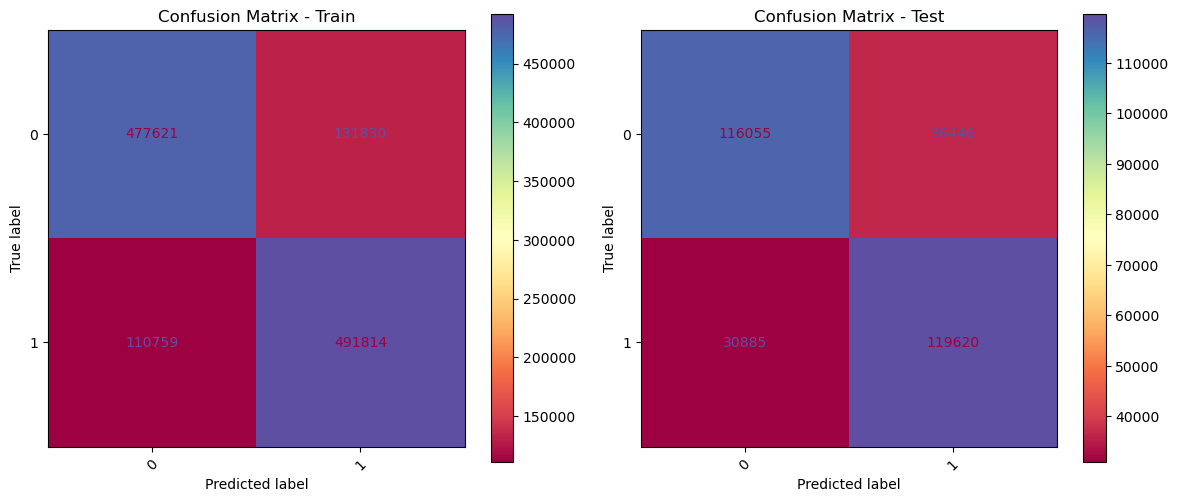

In [31]:
lr = LogisticRegression(max_iter=1000, solver='saga', n_jobs=-1, verbose=1)
lr.fit(X_train_tfidf, y_train.ravel())

lr_train_pred = lr.predict(X_train_tfidf)
lr_test_pred = lr.predict(X_test_tfidf)

C_train_lr = confusion_matrix(y_train, lr_train_pred)
C_test_lr = confusion_matrix(y_test, lr_test_pred)

print("Classification Report (Train):\n", classification_report(y_train, lr_train_pred))
print("Classification Report (Test):\n", classification_report(y_test, lr_test_pred))

fig, axes = plt.subplots(1, 2, figsize=(12,5))

matrix_train = ConfusionMatrixDisplay(C_train_lr, display_labels=mnb.classes_)
matrix_train.plot(ax=axes[0], cmap="Spectral", xticks_rotation=45, values_format='d')
axes[0].set_title("Confusion Matrix - Train")

matrix_test = ConfusionMatrixDisplay(C_test_lr, display_labels=mnb.classes_)
matrix_test.plot(ax=axes[1], cmap="Spectral", xticks_rotation=45, values_format='d')
axes[1].set_title("Confusion Matrix - Test")

plt.tight_layout()
plt.show()

In [32]:
lr_train_result = score_table('lr (train)', lr_train_pred, y_train)
lr_test_result = score_table('lr (test)', lr_test_pred, y_test)

lr_results = pd.concat([lr_train_result, lr_test_result], axis=0)
lr_results

,Model,Accuracy,Precision,Recall,f1
0,lr (train),0.799848,0.800185,0.799940,0.799821
0,lr (test),0.777790,0.778141,0.777901,0.777759


## 4. Model Application: Word2Vec and Neural Network

### 4.1 Word2Vec:

#### Embedding:

In [31]:
documents = [_text.split() for _text in X_train]

W2V_SIZE = 300
W2V_WINDOW = 7
W2V_EPOCH = 32
W2V_MIN_COUNT = 10

w2v_model = gensim.models.Word2Vec(
    vector_size = W2V_SIZE,
    window = W2V_WINDOW,
    min_count = W2V_MIN_COUNT,
    workers = 8
)

w2v_model.build_vocab(documents)
w2v_model.train(documents, total_examples=w2v_model.corpus_count, epochs=W2V_EPOCH)

print(w2v_model.wv.most_similar("love"))


[('luv', 0.601460874080658), ('loves', 0.5725365877151489), ('loved', 0.5282453298568726), ('looove', 0.5265023708343506), ('adore', 0.5130980014801025), ('looooove', 0.504425048828125), ('amazing', 0.49579373002052307), ('awesome', 0.476122111082077), ('loooove', 0.4666321873664856), ('loove', 0.46022823452949524)]


#### Tokenize:

In [32]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index) + 1
print("Total words", vocab_size)

Total words 216112


In [33]:
SEQUENCE_LENGTH = 300

X_train_w2v = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=SEQUENCE_LENGTH)
X_test_w2v = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=SEQUENCE_LENGTH)
print(X_train_w2v[0])
print(X_test_w2v[1])

[    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0   

#### Label Encoder:

In [34]:
encoder = LabelEncoder()
encoder.fit(y_train.tolist())

y_train_w2v = encoder.transform(y_train.tolist()).reshape(-1,1)
y_test_w2v = encoder.transform(y_test.tolist()).reshape(-1,1)

print("x_train", X_train_w2v.shape)
print("y_train", y_train.shape)

print("x_test", X_test_w2v.shape)
print("y_test", y_test.shape)

x_train (1212024, 300)
y_train (1212024,)
x_test (303006, 300)
y_test (303006,)


#### Embedding Layer:

In [35]:
embedding_matrix = np.zeros((vocab_size, W2V_SIZE))
for word, i in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]
        
print(embedding_matrix.shape)

embedding_layer = Embedding(
    vocab_size, 
    W2V_SIZE, 
    weights=[embedding_matrix], 
    input_length=SEQUENCE_LENGTH, 
    trainable=False
)

(216112, 300)


/home/liyibin/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


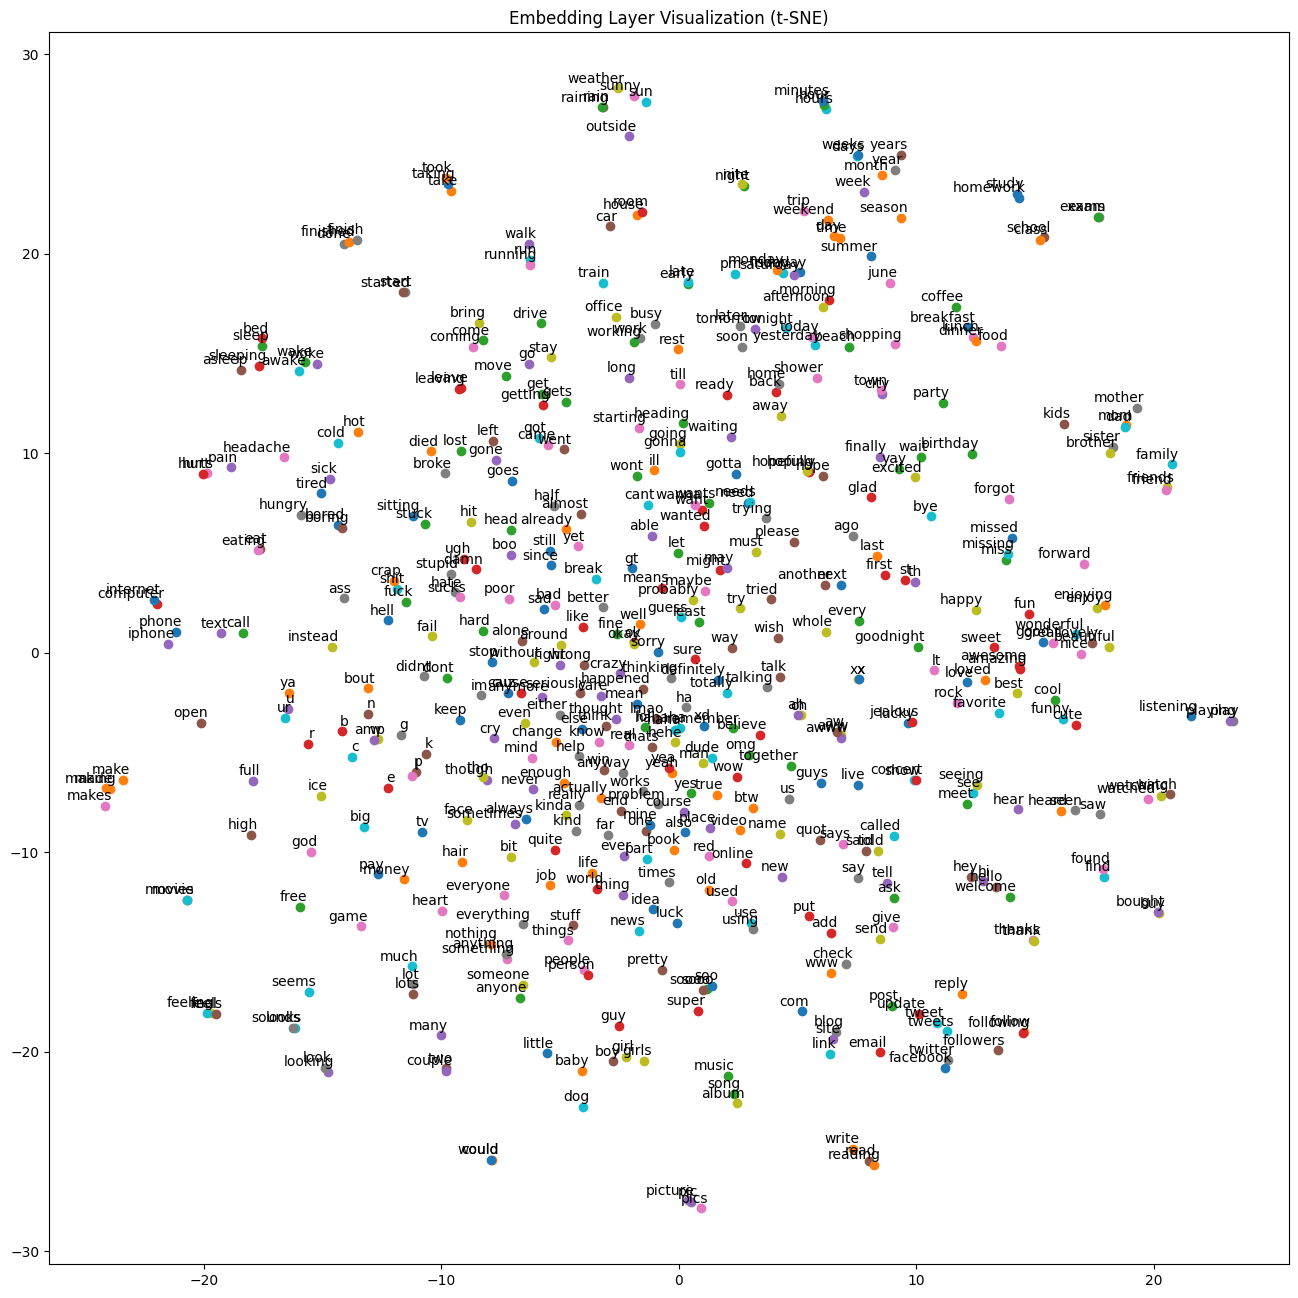

In [36]:
N = 500
labels = []
tokens = []

for word, i in tokenizer.word_index.items():
    if i >= N:
        continue
    if word in w2v_model.wv:
        tokens.append(w2v_model.wv[word])
        labels.append(word)

tokens = np.array(tokens)

tsne_model = TSNE(perplexity=30, n_components=2, init='pca', n_iter=5000)
new_values = tsne_model.fit_transform(tokens)

x = new_values[:, 0]
y = new_values[:, 1]

plt.figure(figsize=(16, 16))
for i in range(len(x)):
    plt.scatter(x[i], y[i])
    plt.annotate(labels[i],
                 xy=(x[i], y[i]),
                 xytext=(5, 2),
                 textcoords='offset points',
                 ha='right',
                 va='bottom')
plt.title("Embedding Layer Visualization (t-SNE)")
plt.show()

### 4.2 Dense Neural Network:

In [37]:
model = Sequential()

model.add(embedding_layer)

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(3, activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 300, 300)          64833600  
                                                                 
 flatten (Flatten)           (None, 90000)             0         
                                                                 
 dense (Dense)               (None, 128)               11520128  
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 3)                

In [38]:
model.fit(
    X_train_w2v, y_train_w2v,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5


2025-05-05 10:18:30.523672: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-05-05 10:18:30.584920: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f40a4046c60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-05-05 10:18:30.584945: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti, Compute Capability 8.6
2025-05-05 10:18:30.619264: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-05 10:18:30.670113: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2025-05-05 10:18:30.871611: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of th

8523/8523 [==============================] - 30s 3ms/step - loss: 0.4986 - accuracy: 0.7579 - val_loss: 0.4811 - val_accuracy: 0.7680
Epoch 2/5
8523/8523 [==============================] - 29s 3ms/step - loss: 0.4771 - accuracy: 0.7716 - val_loss: 0.4743 - val_accuracy: 0.7716
Epoch 3/5
8523/8523 [==============================] - 29s 3ms/step - loss: 0.4630 - accuracy: 0.7795 - val_loss: 0.4716 - val_accuracy: 0.7727
Epoch 4/5
8523/8523 [==============================] - 29s 3ms/step - loss: 0.4503 - accuracy: 0.7868 - val_loss: 0.4725 - val_accuracy: 0.7730
Epoch 5/5
8523/8523 [==============================] - 29s 3ms/step - loss: 0.4384 - accuracy: 0.7933 - val_loss: 0.4751 - val_accuracy: 0.7733


In [39]:
y_pred_probs_nn = model.predict(X_test_w2v)
y_pred_nn = np.argmax(y_pred_probs_nn, axis=1)

9469/9469 [==============================] - 8s 851us/step


Classification Report (Test):
               precision    recall  f1-score   support

           0       0.78      0.77      0.77    152501
           1       0.77      0.78      0.77    150505

    accuracy                           0.77    303006
   macro avg       0.77      0.77      0.77    303006
weighted avg       0.77      0.77      0.77    303006



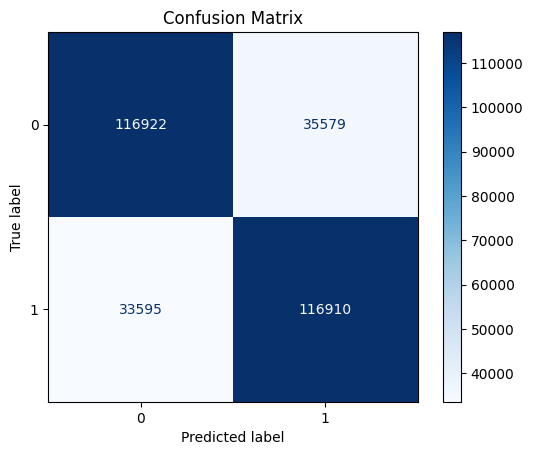

In [40]:
print("Classification Report (Test):\n", classification_report(y_test_w2v, y_pred_nn))

cm = confusion_matrix(y_test_w2v, y_pred_nn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

## 5. Results & Future Steps:

Based on the evaluation metrics from our models, it appears that all 3 models produce similar results with around 77-81% accuracy. TF-IDF word embedding in combination with either multinomial Naive Bayes or logistic regression performed faster than the neural network model. They both predicted the proper sentiment of a tweet with appoximately 80% accuracy.

On the other hand, Word2Vector embedding and the neural network model performed similarly, with accuracy slightly lower at 77% compared to the other models. Although it took longer to execute and performed slightly below the former models, it has potential to improve its learning capability with additional layers and hyperparameter tuning. Challenges arise here due to the heavy computational cost of neural networks. Adding additional layers may cause length runtimes that one may or may not consider reasonable for the analysis at hand. Regardless, the neural network has potential to improve its performance more than the other models are capable of.

Future implementations of sentiment analysis on this dataset could consider using transformer models or other computationally heavy models that would be able to more accurately analyze the content of words within user tweets. Although difficult to compute, experimentation with these models could help improve accuracy beyond 80% while simultaneously improving other evaluation metrics as well. Experimentation with other word embedding techniques could also be done to improve performance for future sentiment analyses.

## Other Notes:

### Dataset:
- Link to dataset (Kaggle): https://www.kaggle.com/datasets/kazanova/sentiment140/data

### Members and Contributions:
- Joey Wong
    - Reading the data and exploratory data analysis
    - Data cleaning and preprocessing
    - TF-IDF & Multinomial Naive Bayes
    - TF-IDF & Logistic Regression
    - Data visualizations
- Yibin Li
    - Reading the data and exploratory data analysis
    - Data cleaning and preprocessing
    - Word2Vector & Neural Network
    - Data visualizations